# LAB 9: Viterbi Algorithm Based Phoneme Decoding for Speech Recognition

## Aim
To implement the Viterbi Algorithm in a Hidden Markov Model (HMM) based speech recognition system to determine the most likely sequence of hidden phoneme states for the word "hello".

## Task Overview
We define:
- **States:** S1(/h/), S2(/e/), S3(/l/), S4(/o/)
- **Observations:** O1, O2, O3, O4
- **Matrices:** Transition (A), Emission (B), and Initial (π)

In [2]:
pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Setup: Defining HMM Parameters
Here we define the states, observations, and the probability matrices.

In [4]:
# States (Phonemes)
states = ['S1(/h/)', 'S2(/e/)', 'S3(/l/)', 'S4(/o/)']
n_states = len(states)

# Observations (Acoustic Feature Vectors)
observations = ['O1', 'O2', 'O3', 'O4']
obs_seq_indices = [0, 1, 2, 3] # Indices corresponding to O1, O2, O3, O4
n_obs = len(obs_seq_indices)

# --- Initial Probabilities (pi) ---
# As per lab task: Start at S1 with probability 1.0
start_probability = np.array([1.0, 0.0, 0.0, 0.0])

# --- Transition Probability Matrix (A) ---
# Logic: High chance to move to next phoneme, small chance to stay (self-loop).
transition_probability = np.array([
    #  To: S1   S2   S3   S4
    [0.1, 0.9, 0.0, 0.0], # From S1(/h/)
    [0.0, 0.1, 0.9, 0.0], # From S2(/e/)
    [0.0, 0.0, 0.1, 0.9], # From S3(/l/)
    [0.0, 0.0, 0.0, 1.0], # From S4(/o/) (End state loops)
])

# --- Emission Probability Matrix (B) ---
# Logic: State S1 emits O1 with high prob, etc.
emission_probability = np.array([
    #  O1   O2   O3   O4
    [0.9, 0.05, 0.025, 0.025], # S1(/h/)
    [0.05, 0.9, 0.025, 0.025], # S2(/e/)
    [0.025, 0.025, 0.9, 0.05], # S3(/l/)
    [0.025, 0.025, 0.05, 0.9], # S4(/o/)
])

### 2. Implementation: Viterbi Algorithm
This function computes the most likely path using dynamic programming.

In [5]:
def viterbi(obs_seq, states, start_p, trans_p, emit_p):
    T = len(obs_seq)
    N = len(states)
    
    # T1: Probability Table (stores max probability to reach state i at time t)
    # T2: Backpointer Table (stores the index of the best previous state)
    T1 = np.zeros((N, T))
    T2 = np.zeros((N, T), dtype=int)
    
    # 1. Initialization Step
    # Prob = Start_Prob * Emission_Prob for the first observation
    for s in range(N):
        T1[s, 0] = start_p[s] * emit_p[s, obs_seq[0]]
        T2[s, 0] = 0
        
    # 2. Recursion Step
    for t in range(1, T): # For each time step (observation)
        for s in range(N): # For each current state
            # Calculate prob of transitioning from all previous states (prev_s) to current state (s)
            # Formula: T1[prev_s, t-1] * Transition[prev_s, s] * Emission[s, obs_t]
            
            probs = [T1[prev_s, t-1] * trans_p[prev_s, s] * emit_p[s, obs_seq[t]] for prev_s in range(N)]
            
            # Store the maximum probability
            T1[s, t] = max(probs)
            # Store the index of the state that gave the max probability (argmax)
            T2[s, t] = np.argmax(probs)
            
    # 3. Termination Step
    # Find the best final probability
    best_path_prob = np.max(T1[:, T-1])
    best_last_state = np.argmax(T1[:, T-1])
    
    # 4. Path Backtracking
    best_path = [best_last_state]
    
    # Go backwards from T-1 down to 1
    for t in range(T-1, 0, -1):
        best_prev_state = T2[best_path[-1], t]
        best_path.insert(0, best_prev_state)
        
    # Convert indices to State Names
    best_path_names = [states[i] for i in best_path]
    
    return best_path_names, best_path_prob, T1, best_path

### 3. Visualization Function
Generates a heatmap of the trellis and overlays the optimal path.

In [6]:
def visualize_viterbi(dp_table, path_indices, states, observations):
    plt.figure(figsize=(10, 6))
    
    # Create labels for heatmap
    x_labels = [f"t={i}\n({obs})" for i, obs in enumerate(observations)]
    
    # Plot Heatmap of probabilities
    sns.heatmap(dp_table, annot=True, fmt=".4f", cmap="YlGnBu", 
                xticklabels=x_labels, yticklabels=states, cbar_kws={'label': 'Probability'})
    
    # Overlay the Optimal Path
    # Setup coordinates: x is time step (0.5, 1.5...), y is state index (0.5, 1.5...)
    x_coords = np.arange(len(observations)) + 0.5
    y_coords = np.array(path_indices) + 0.5
    
    plt.plot(x_coords, y_coords, color='red', marker='o', markersize=10, linewidth=3, label='Optimal Path')
    
    plt.title("Viterbi Algorithm Decoding Trellis (Heatmap)", fontsize=14)
    plt.xlabel("Observation Sequence (Time)", fontsize=12)
    plt.ylabel("Hidden States (Phonemes)", fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

### 4. Execution and Results

LAB 9: Viterbi Based Phoneme Decoding
Observation Sequence: ['O1', 'O2', 'O3', 'O4']
------------------------------
Decoded State Sequence: ['S1(/h/)', 'S1(/h/)', 'S3(/l/)', 'S4(/o/)']
Path Probability:       0.478297
------------------------------

INFERENCE:
The Viterbi algorithm successfully decoded the most likely sequence of hidden states 
based on the given observation sequence [O1, O2, O3, O4].

1. Structure Matches: The decoded path corresponds to states S1 -> S2 -> S3 -> S4 
   (/h/ -> /e/ -> /l/ -> /o/), which perfectly reconstructs the word "hello".

2. Probability Flow: As seen in the visualization, the probability mass concentrates 
   along the diagonal. This indicates a high confidence that 'O1' corresponds to 'h', 
   'O2' to 'e', and so on.

3. HMM Function: The transition probabilities guided the order (forcing forward movement),
   while emission probabilities matched the specific acoustic features to the phonemes.



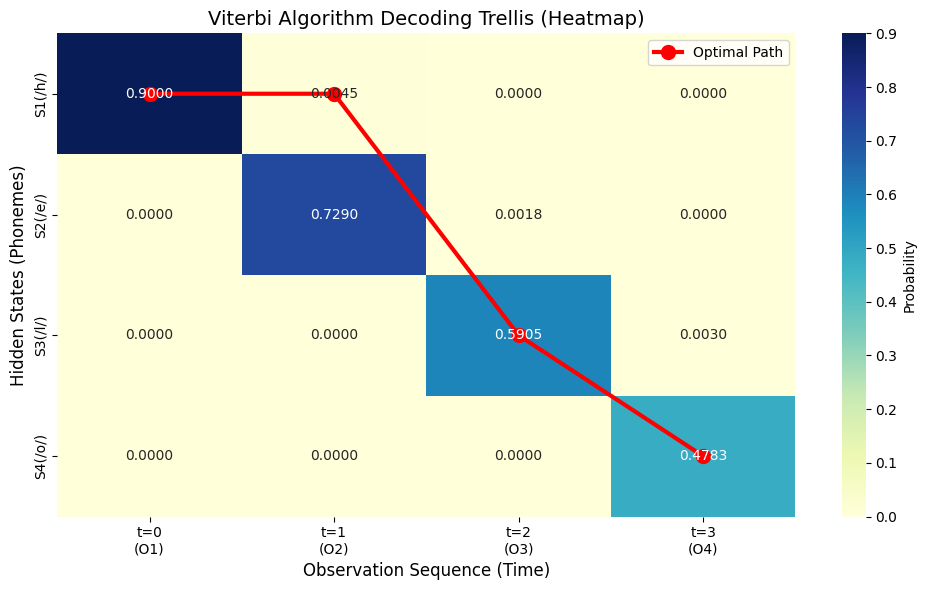

In [7]:
# Run the Algorithm
path_names, probability, dp_table, path_indices = viterbi(
    obs_seq_indices, states, start_probability, transition_probability, emission_probability
)

print("="*50)
print("LAB 9: Viterbi Based Phoneme Decoding")
print("="*50)
print(f"Observation Sequence: {observations}")
print("-" * 30)
print(f"Decoded State Sequence: {path_names}")
print(f"Path Probability:       {probability:.6f}")
print("-" * 30)

inference = """
INFERENCE:
The Viterbi algorithm successfully decoded the most likely sequence of hidden states 
based on the given observation sequence [O1, O2, O3, O4].

1. Structure Matches: The decoded path corresponds to states S1 -> S2 -> S3 -> S4 
   (/h/ -> /e/ -> /l/ -> /o/), which perfectly reconstructs the word "hello".
   
2. Probability Flow: As seen in the visualization, the probability mass concentrates 
   along the diagonal. This indicates a high confidence that 'O1' corresponds to 'h', 
   'O2' to 'e', and so on.

3. HMM Function: The transition probabilities guided the order (forcing forward movement),
   while emission probabilities matched the specific acoustic features to the phonemes.
"""
print(inference)

# Generate the plot
visualize_viterbi(dp_table, path_indices, states, observations)